# НИРС по анализу данных.

## Построение модели машинного обучения для решения задач классификации.

В качестве набора данных мы будем использовать набор с метаданными и оценками различных видов рамена - https://www.kaggle.com/datasets/residentmario/ramen-ratings?select=ramen-ratings.csv

Эта задача является актуальной в рамках современных методов анализа пользовательских предпочтений и автоматизированного предсказания качества продукта на основе его характеристик. Прогнозирование рейтингов продуктов питания может быть полезным как для производителей, стремящихся улучшить рецептуру и упаковку, так и для потребителей, ищущих рекомендации. В данном проекте мы будем использовать методы машинного обучения для построения модели, способной предсказывать рейтинг рамена по его метаданным.

Датасет состоит из трех файлов:
- ramen_train.csv - обучающая выборка
- ramen_test.csv - тестовая выборка
- ramen_test_full.csv - полный датасет для теста

Каждый файл содержит следующие колонки:
- Brand (Бренд) - бренд производителя рамена.
- Variety (Разновидность) -  название продукта.
- Style  (Тип) - тип упаковки (например, Cup — стакан, Pack — пакет, Bowl — миска и т.д.).
- Country (Страна) - страна происхождения продукта.
- Stars (Оценка) - оценка качества рамена от 0 до 5, выставленная рецензентом (числовой признак; является целевой переменной для задачи регрессии).

В рассматриваемом примере будем решать задачу классификации:
- Для решения **задачи классификации** в качестве целевого признака будем использовать "Stars".

### Импорт библиотек
Импортируем библиотеки с помощью команды import. Как правило, все команды import размещают в первых ячейках ноутбука.

In [73]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, median_absolute_error, r2_score 
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.svm import SVC, NuSVC, LinearSVC, OneClassSVM, SVR, NuSVR, LinearSVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
%matplotlib inline 
sns.set(style="ticks")

### Загрузка данных

Загрузим файлы датасета в помощью библиотеки Pandas. 

In [74]:
# Обучающая выборка
original_train = pd.read_csv('data/ramen_train_multiclass.csv', sep=",")
# Тестовая выборка (два файла)
original_test_1 = pd.read_csv('data/ramen_test_multiclass.csv', sep=",")
original_test_2 = pd.read_csv('data/ramen_test_full_multiclass.csv', sep=",")

In [75]:
# Удалим дубликаты записей, если они присутствуют
train = original_train.drop_duplicates()
test_1 = original_test_1.drop_duplicates()
test_2 = original_test_2.drop_duplicates()

## Проведение разведочного анализа данных. Построение графиков, необходимых для понимания структуры данных. Анализ и заполнение пропусков в данных.

### Основные характеристики датасетов

In [76]:
# Первые 5 строк датасета
train.head()

,Brand,Variety,Style,Country,Stars
0,282,1279,5,17,medium
1,163,98,1,33,medium
2,160,898,4,35,low
3,63,1436,4,0,very_low
4,23,2153,5,34,medium


In [77]:
# Размер обучающего датасета - 8143 строк, 7 колонок
train.shape, test_1.shape, test_2.shape

((2060, 5), (516, 5), (2545, 5))

In [78]:
# Список колонок
train.columns

Index(['Brand', 'Variety', 'Style', 'Country', 'Stars'], dtype='object')

In [79]:
# Список колонок с типами данных 
# убедимся что типы данных одинаковы в обучающей и тестовых выборках
train.dtypes

Brand       int64
Variety     int64
Style       int64
Country     int64
Stars      object
dtype: object

In [80]:
# Проверим наличие пустых значений
train.isnull().sum()

Brand      0
Variety    0
Style      0
Country    0
Stars      0
dtype: int64

In [81]:
test_1.isnull().sum()

Brand      0
Variety    0
Style      0
Country    0
Stars      0
dtype: int64

In [82]:
test_2.isnull().sum()

Brand      0
Variety    0
Style      0
Country    0
Stars      0
dtype: int64

**Вывод. Представленный набор данных не содержит пропусков ни в обучающей, ни в тестовой выборках.**

### Feature Engineering

In [83]:
# Feature engineering function
def add_features(df):
    df = df.copy()
    df['Variety'] = df['Variety'].fillna('').astype(str)
    star_mapping = {
        'very_low': 1.0,
        'low': 2.0,
        'medium': 3.0,
        'high': 4.0
    }
    df['Stars_numeric'] = df['Stars'].map(star_mapping)
    brand_freq = df['Brand'].value_counts(normalize=True) 
    df['Brand_Popularity'] = df['Brand'].map(brand_freq) # Популярность бренда: доля записей данного бренда в датасете
    brand_mean = df.groupby('Brand')['Stars_numeric'].transform('mean')
    df['Brand_Mean_Rating'] = brand_mean # Средний рейтинг бренда — отражает «репутацию»
    country_mean = df.groupby('Country')['Stars_numeric'].transform('mean')
    df['Country_Mean_Rating'] = country_mean # Средний рейтинг по стране — региональный контекст
    df['Is_Cup'] = (df['Style'] == 5).astype(int) # Признак «это Cup ?» — бинарный индикатор для простоты упаковки

    df.drop('Stars_numeric', axis=1, inplace=True, errors='ignore')
    return df

In [84]:
# Apply to all datasets
train = add_features(train)
test_1 = add_features(test_1)
test_2 = add_features(test_2)

### Построение графиков для понимания структуры данных

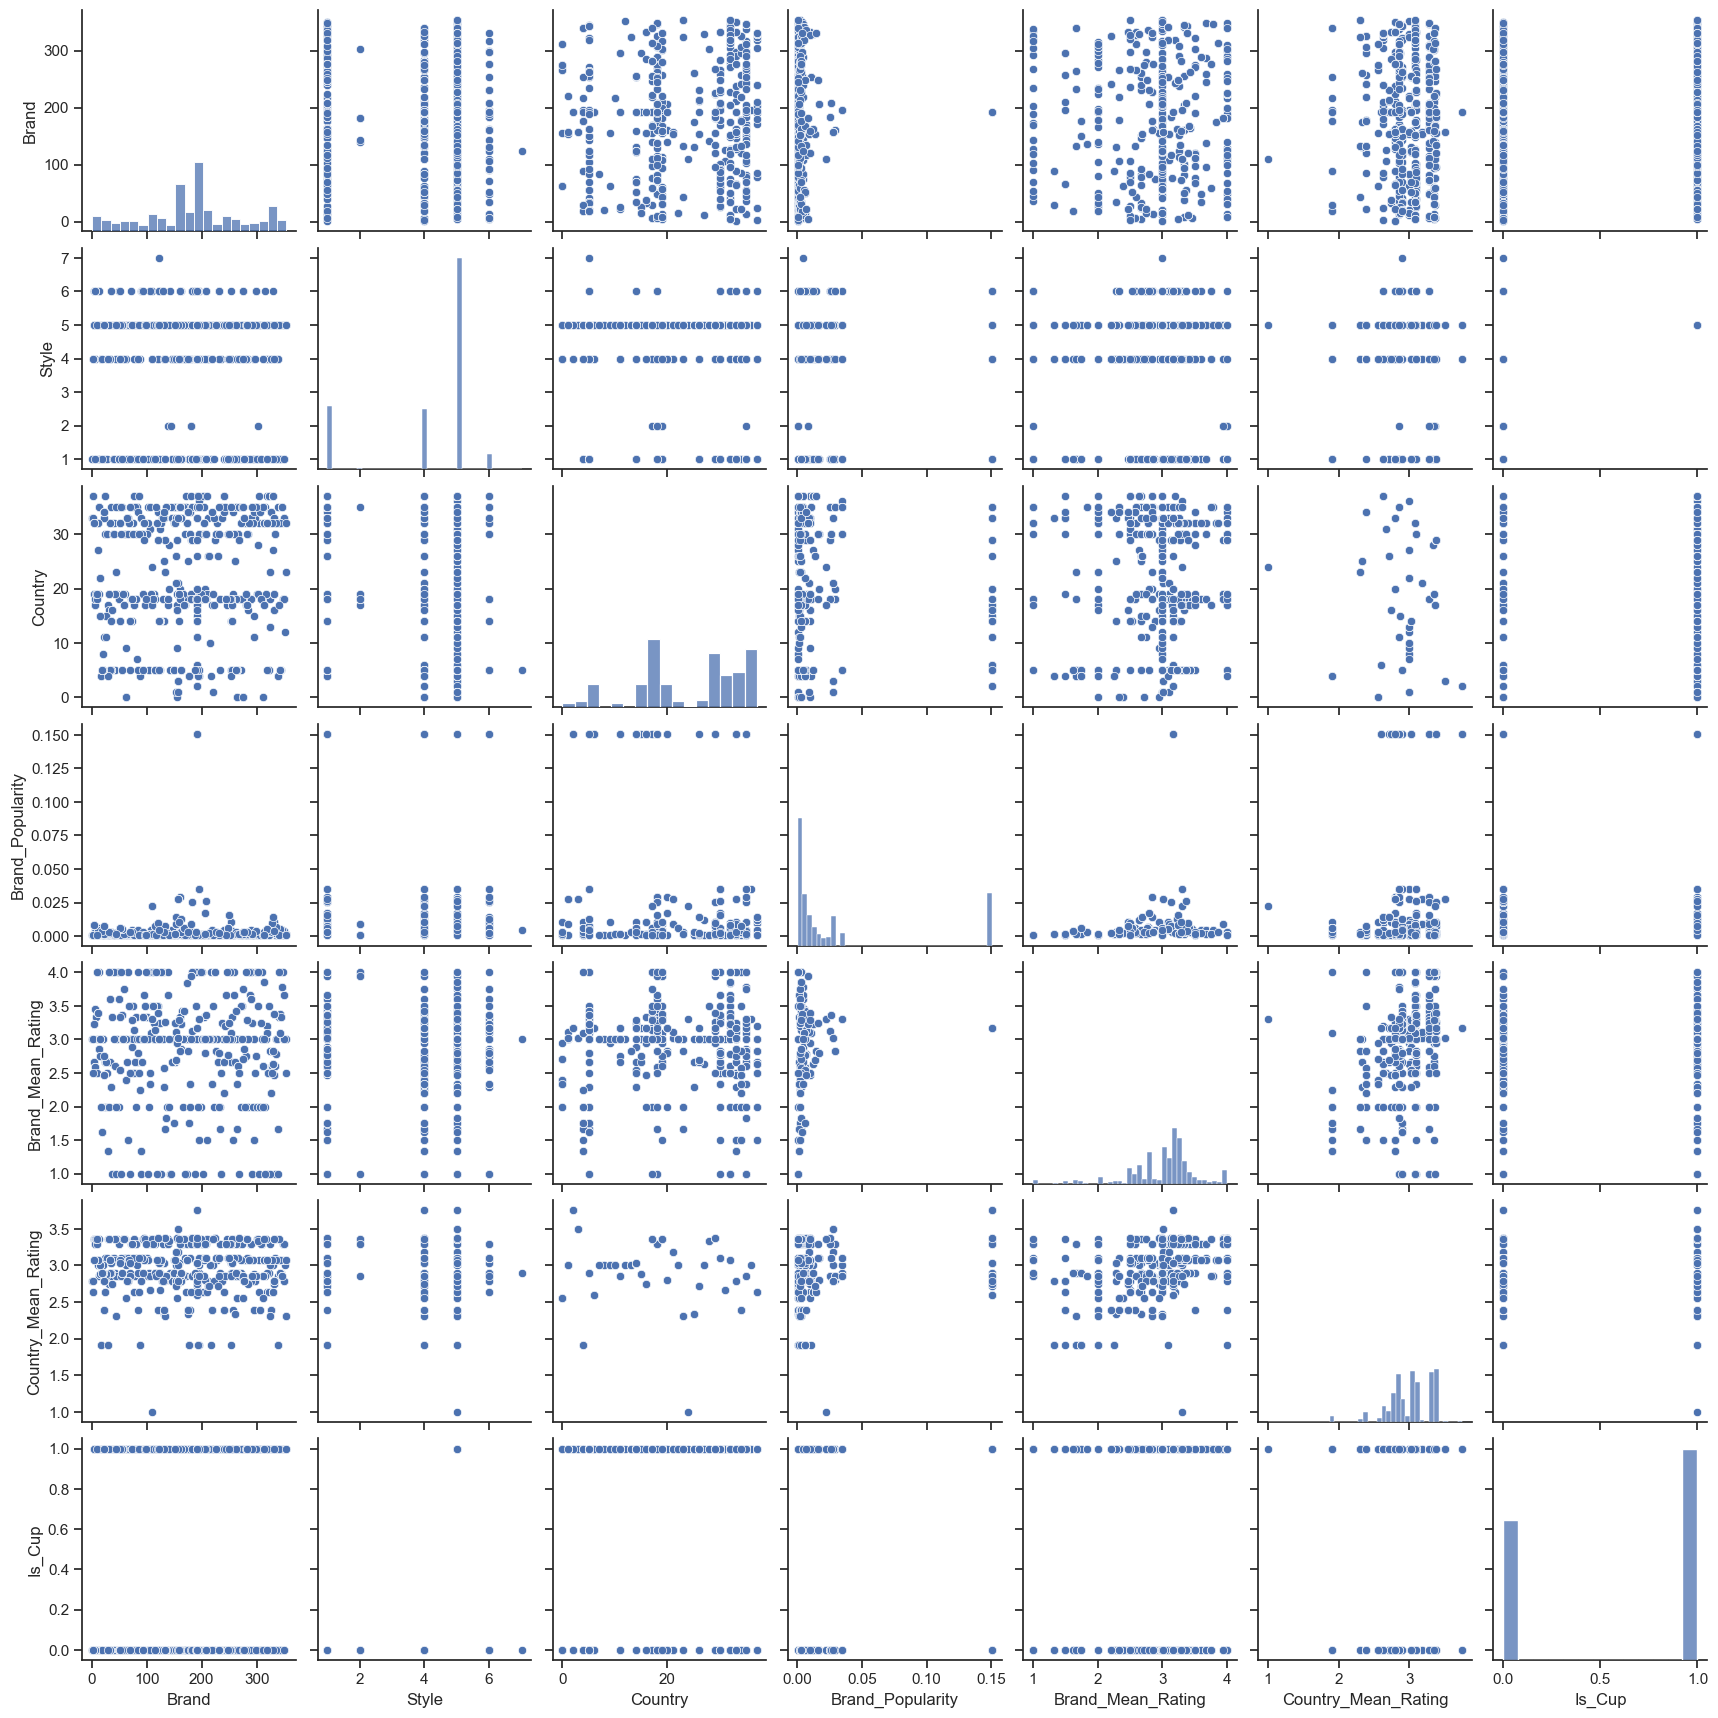

In [85]:
# Парные диаграммы
sns.pairplot(train)

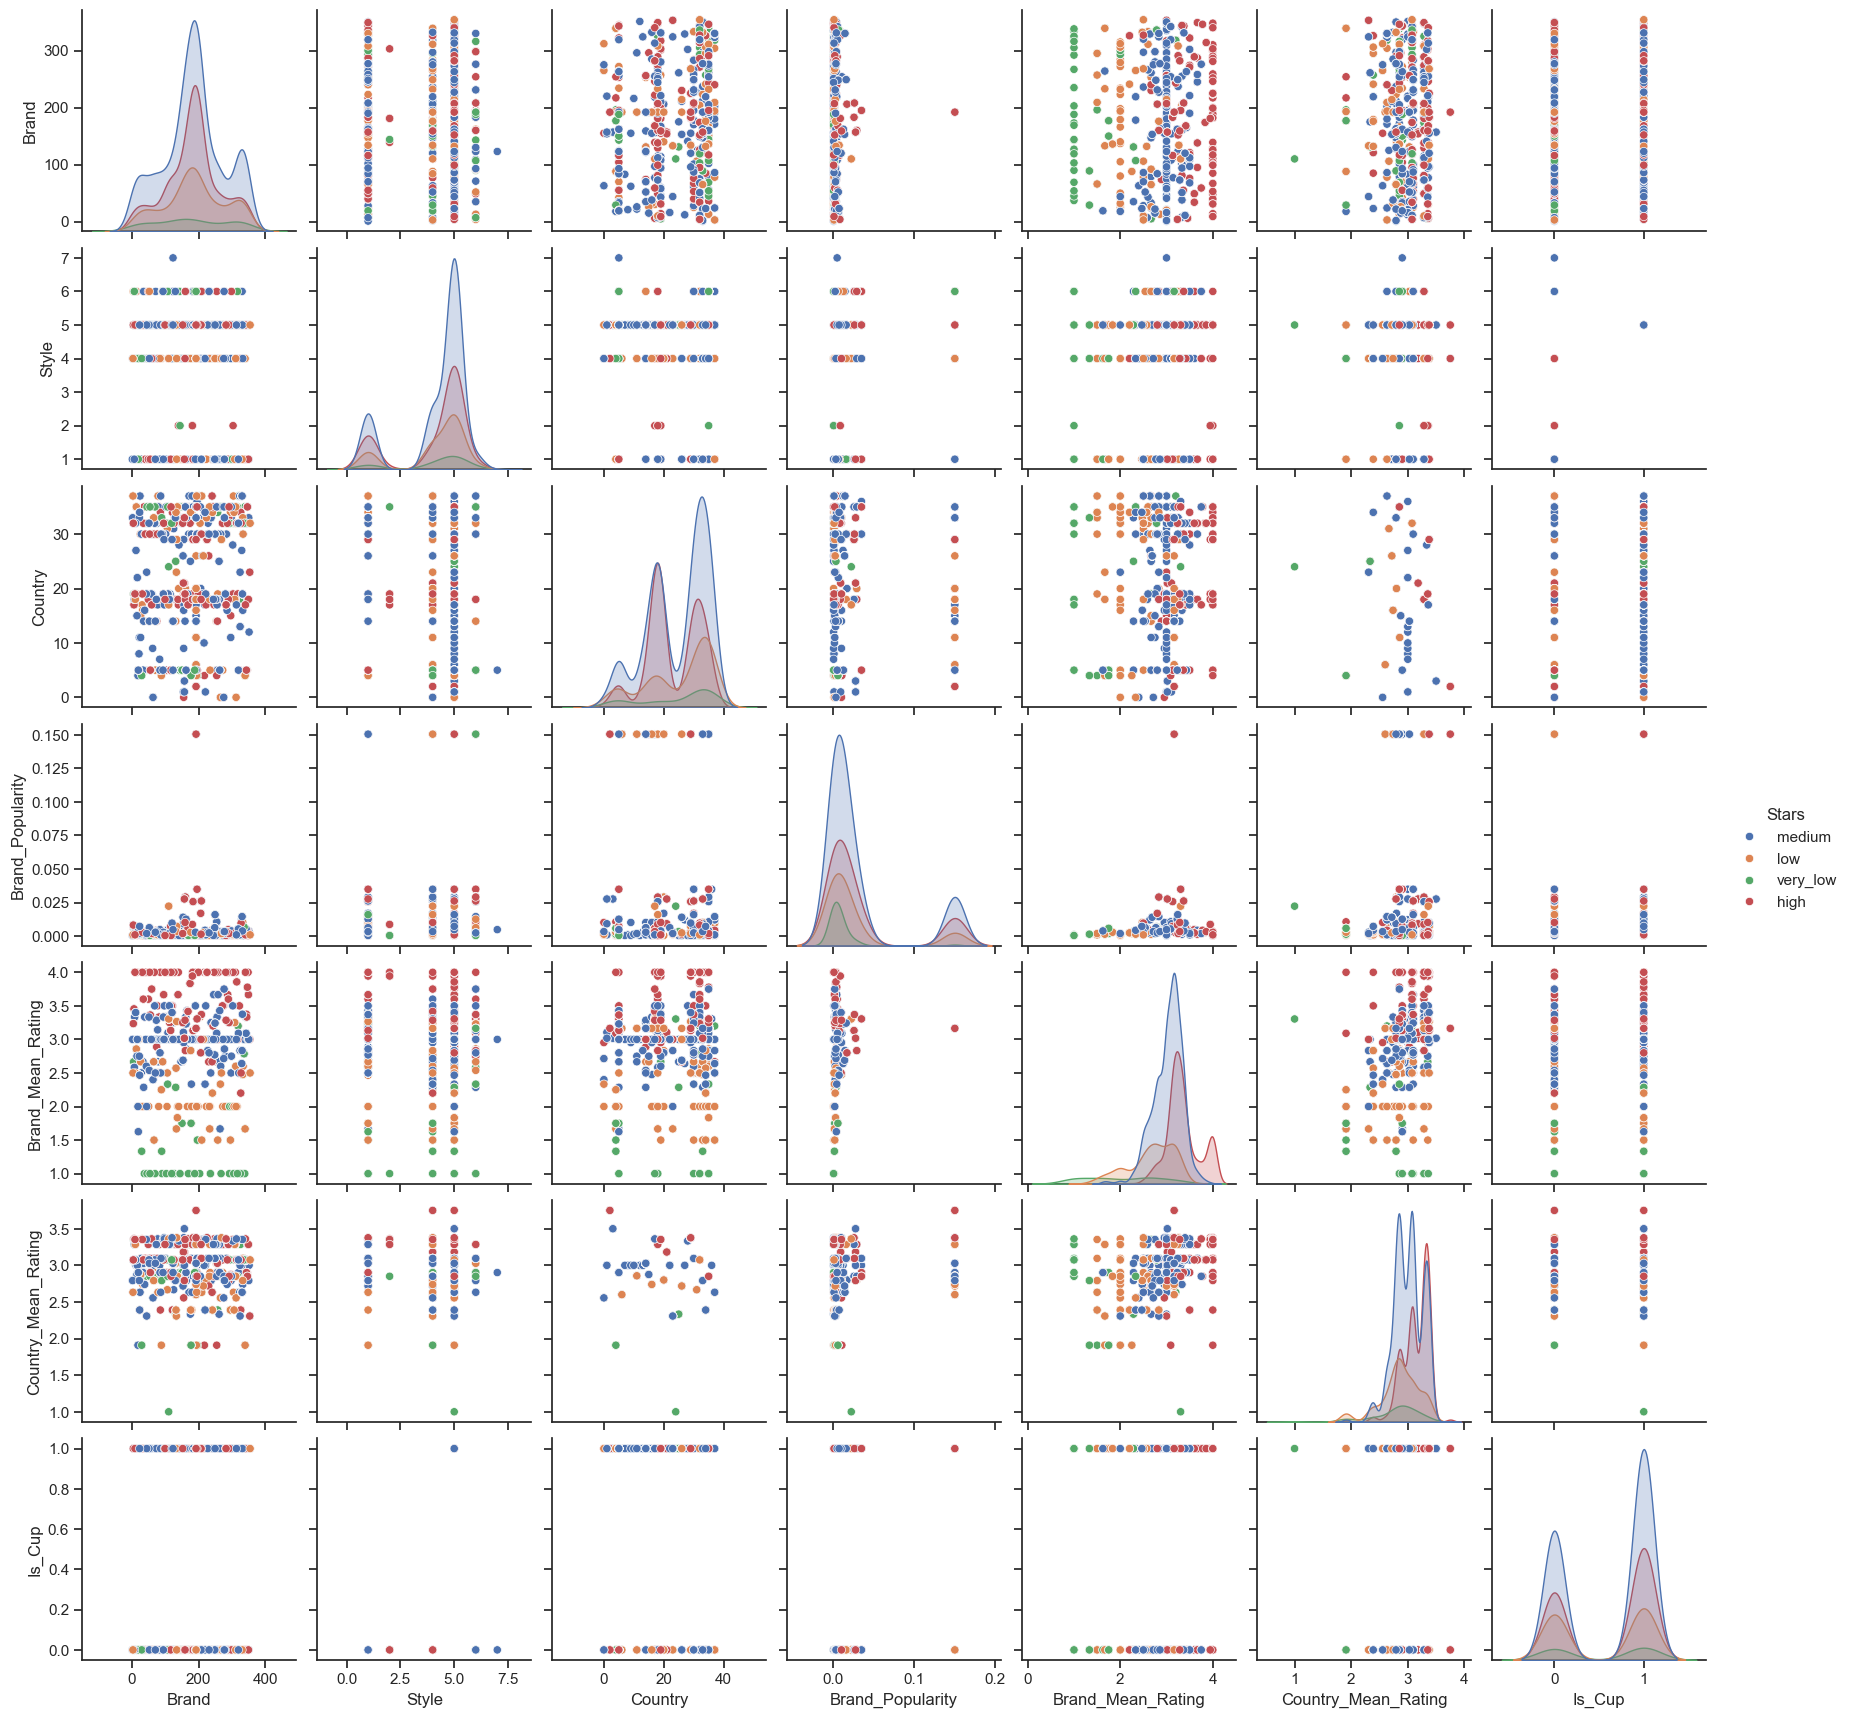

In [86]:
sns.pairplot(train, hue="Stars")

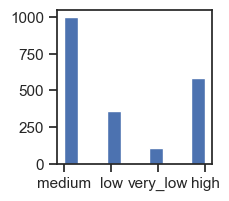

Stars
medium      1002
high         587
low          361
very_low     110
Name: count, dtype: int64

In [87]:
# Оценим дисбаланс классов для Obesity
fig, ax = plt.subplots(figsize=(2,2)) 
plt.hist(train['Stars'])
plt.show()

train['Stars'].value_counts()

In [88]:
# посчитаем дисбаланс классов
total = train.shape[0]
classes = []
class_n=0
for item in train['Stars'].value_counts():
    classes.append(item)
    print('Класс {} составляет {}%.'
      .format(class_n+1, round(classes[class_n] / total, 4)*100))
    class_n+=1
classes

Класс 1 составляет 48.64%.
Класс 2 составляет 28.499999999999996%.
Класс 3 составляет 17.52%.
Класс 4 составляет 5.34%.


[1002, 587, 361, 110]

**Вывод. Дисбаланс классов присутствует, но является приемлемым.**

In [89]:
train.columns

Index(['Brand', 'Variety', 'Style', 'Country', 'Stars', 'Brand_Popularity',
       'Brand_Mean_Rating', 'Country_Mean_Rating', 'Is_Cup'],
      dtype='object')

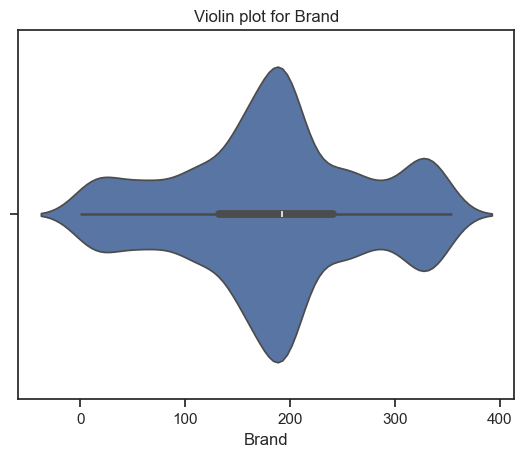

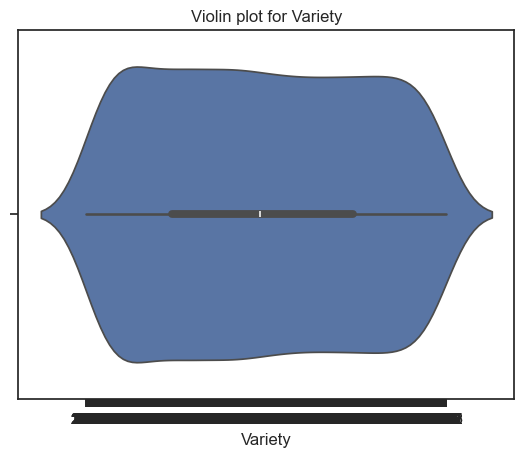

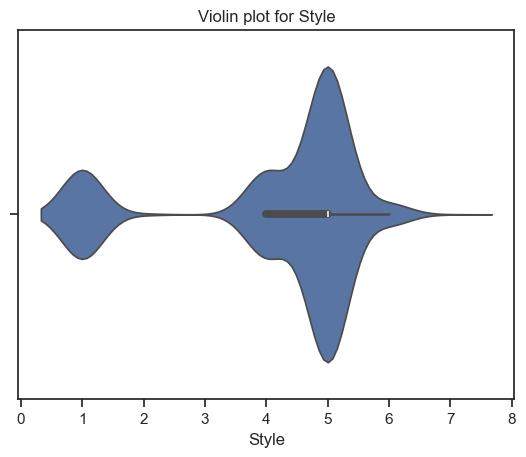

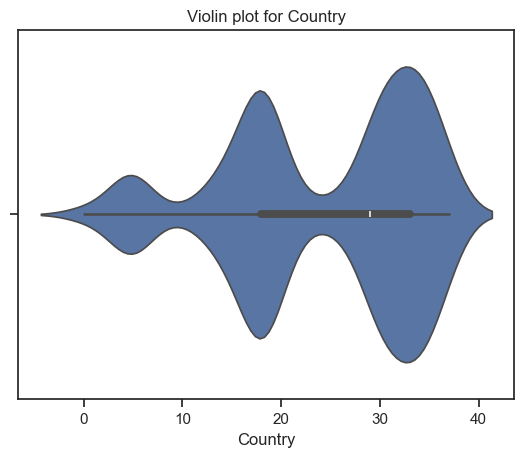

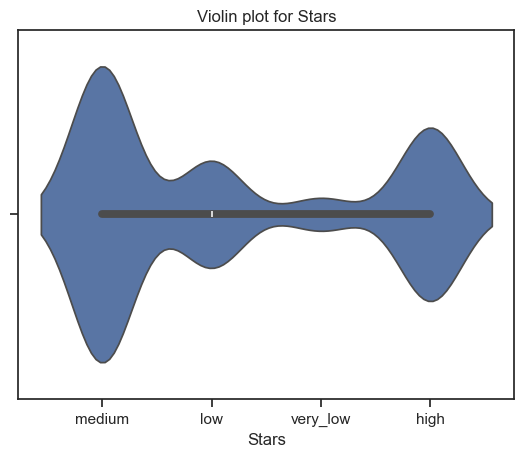

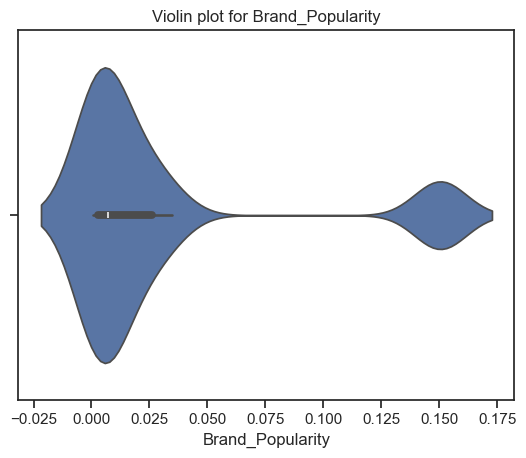

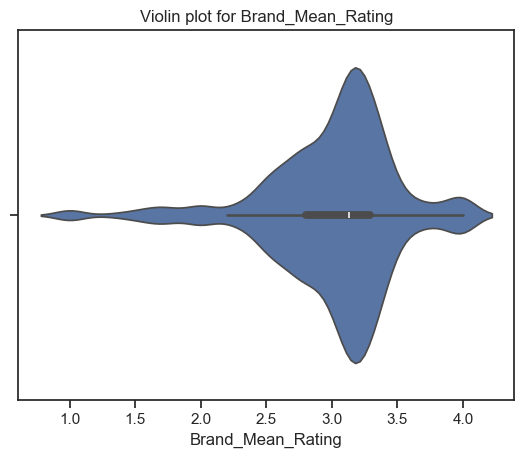

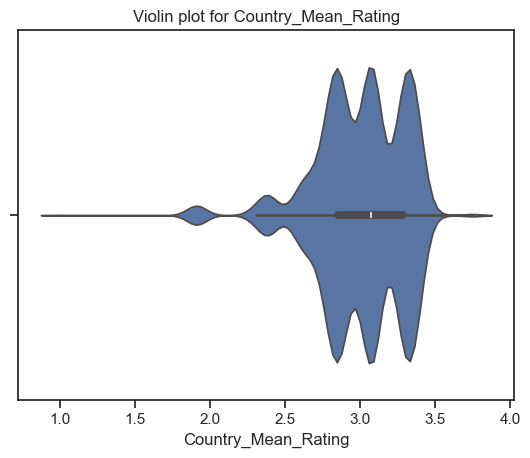

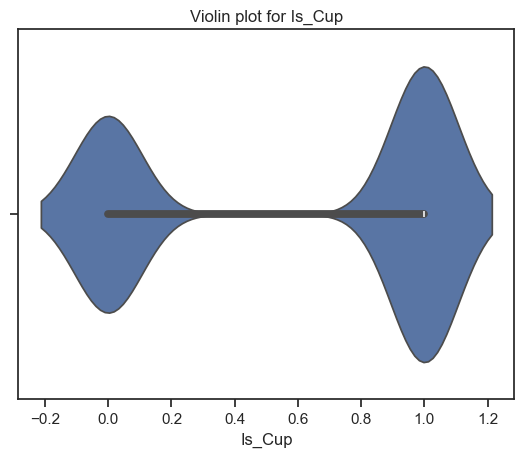

In [90]:
# Скрипичные диаграммы для числовых колонок
for col in ['Brand', 'Variety', 'Style', 'Country', 'Stars', 'Brand_Popularity', 'Brand_Mean_Rating', 'Country_Mean_Rating', 'Is_Cup']:
    sns.violinplot(x=train[col])
    plt.title(f"Violin plot for {col}")
    plt.show()


## Выбор признаков, подходящих для построения моделей. Кодирование категориальных признаков. Масштабирование данных. Формирование вспомогательных признаков, улучшающих качество моделей.

Для построения моделей будем использовать все признаки.

Категориальные признаки присутствуют, требуется кодирование некоторых из них.

Построим некоторые вспомогательные признаки.

Выполним масштабирование данных. Для этого необходимо объединить обучающую и тестовые выборки.

In [98]:
# Создадим вспомогательные колонки, 
# чтобы наборы данных можно было разделить.
train['dataset'] = 'TRAIN'
test_1['dataset'] = 'TEST1'
test_2['dataset'] = 'TEST2'

In [99]:
# Колонки для объединения
join_cols = ['Brand', 'Variety', 'Style', 'Country', 'Stars', 'Brand_Popularity', 'Brand_Mean_Rating', 'Country_Mean_Rating', 'Is_Cup', 'dataset']

In [100]:
data_all = pd.concat([train[join_cols], test_1[join_cols], test_2[join_cols]])

In [101]:
# Проверим корректность объединения
assert data_all.shape[0] == train.shape[0]+test_1.shape[0]+test_2.shape[0]

In [102]:
data_all.head()

,Brand,Variety,Style,Country,Stars,Brand_Popularity,Brand_Mean_Rating,Country_Mean_Rating,Is_Cup,dataset
0,282,1279,5,17,medium,0.003398,3.285714,3.361111,1,TRAIN
1,163,98,1,33,medium,0.003398,2.857143,2.791946,0,TRAIN
2,160,898,4,35,low,0.029126,2.833333,2.850394,0,TRAIN
3,63,1436,4,0,very_low,0.002427,2.400000,2.555556,0,TRAIN
4,23,2153,5,34,medium,0.007282,2.466667,2.389831,1,TRAIN


In [103]:
# Числовые колонки для масштабирования
scale_cols = ['Brand_Popularity','Brand_Mean_Rating','Country_Mean_Rating','Is_Cup']
unsc_cols = ['Brand','Variety','Style','Country']


In [104]:
sc1 = MinMaxScaler()
sc1_data = sc1.fit_transform(data_all[scale_cols])

In [105]:
# Добавим масштабированные данные в набор данных
for i in range(len(scale_cols)):
    col = scale_cols[i]
    new_col_name = col + '_scaled'
    data_all[new_col_name] = sc1_data[:,i]

In [106]:
data_all.head()

,Brand,Variety,Style,Country,Stars,Brand_Popularity,Brand_Mean_Rating,Country_Mean_Rating,Is_Cup,dataset,Brand_Popularity_scaled,Brand_Mean_Rating_scaled,Country_Mean_Rating_scaled,Is_Cup_scaled
0,282,1279,5,17,medium,0.003398,3.285714,3.361111,1,TRAIN,0.020022,0.761905,0.858586,1.0
1,163,98,1,33,medium,0.003398,2.857143,2.791946,0,TRAIN,0.020022,0.619048,0.651617,0.0
2,160,898,4,35,low,0.029126,2.833333,2.850394,0,TRAIN,0.191437,0.611111,0.672870,0.0
3,63,1436,4,0,very_low,0.002427,2.400000,2.555556,0,TRAIN,0.013553,0.466667,0.565657,0.0
4,23,2153,5,34,medium,0.007282,2.466667,2.389831,1,TRAIN,0.045896,0.488889,0.505393,1.0


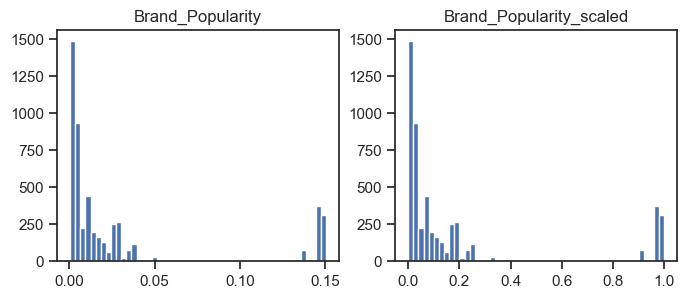

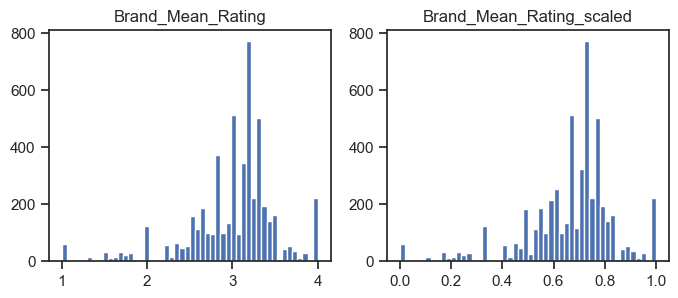

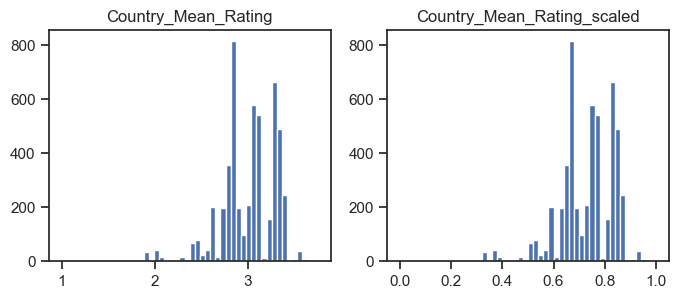

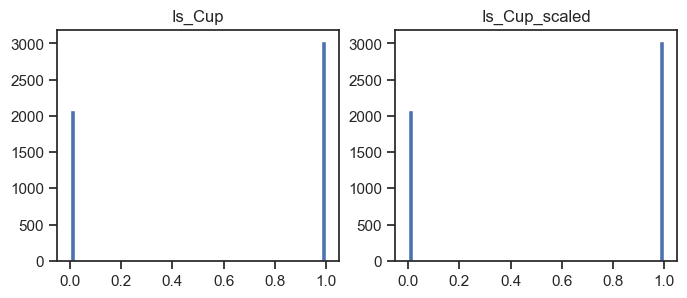

In [107]:
# Проверим, что масштабирование не повлияло на распределение данных
for col in scale_cols:
    col_scaled = col + '_scaled'

    fig, ax = plt.subplots(1, 2, figsize=(8,3))
    ax[0].hist(data_all[col], 50)
    ax[1].hist(data_all[col_scaled], 50)
    ax[0].title.set_text(col)
    ax[1].title.set_text(col_scaled)
    plt.show()

## Проведение корреляционного анализа данных. Формирование промежуточных выводов о возможности построения моделей машинного обучения. 

In [108]:
# Воспользуемся наличием тестовых выборок, 
# включив их в корреляционную матрицу
corr_cols_1 = scale_cols
corr_cols_1

['Brand_Popularity', 'Brand_Mean_Rating', 'Country_Mean_Rating', 'Is_Cup']

In [109]:
scale_cols_postfix = [x+'_scaled' for x in scale_cols]
corr_cols_2 = scale_cols_postfix
corr_cols_2

['Brand_Popularity_scaled',
 'Brand_Mean_Rating_scaled',
 'Country_Mean_Rating_scaled',
 'Is_Cup_scaled']

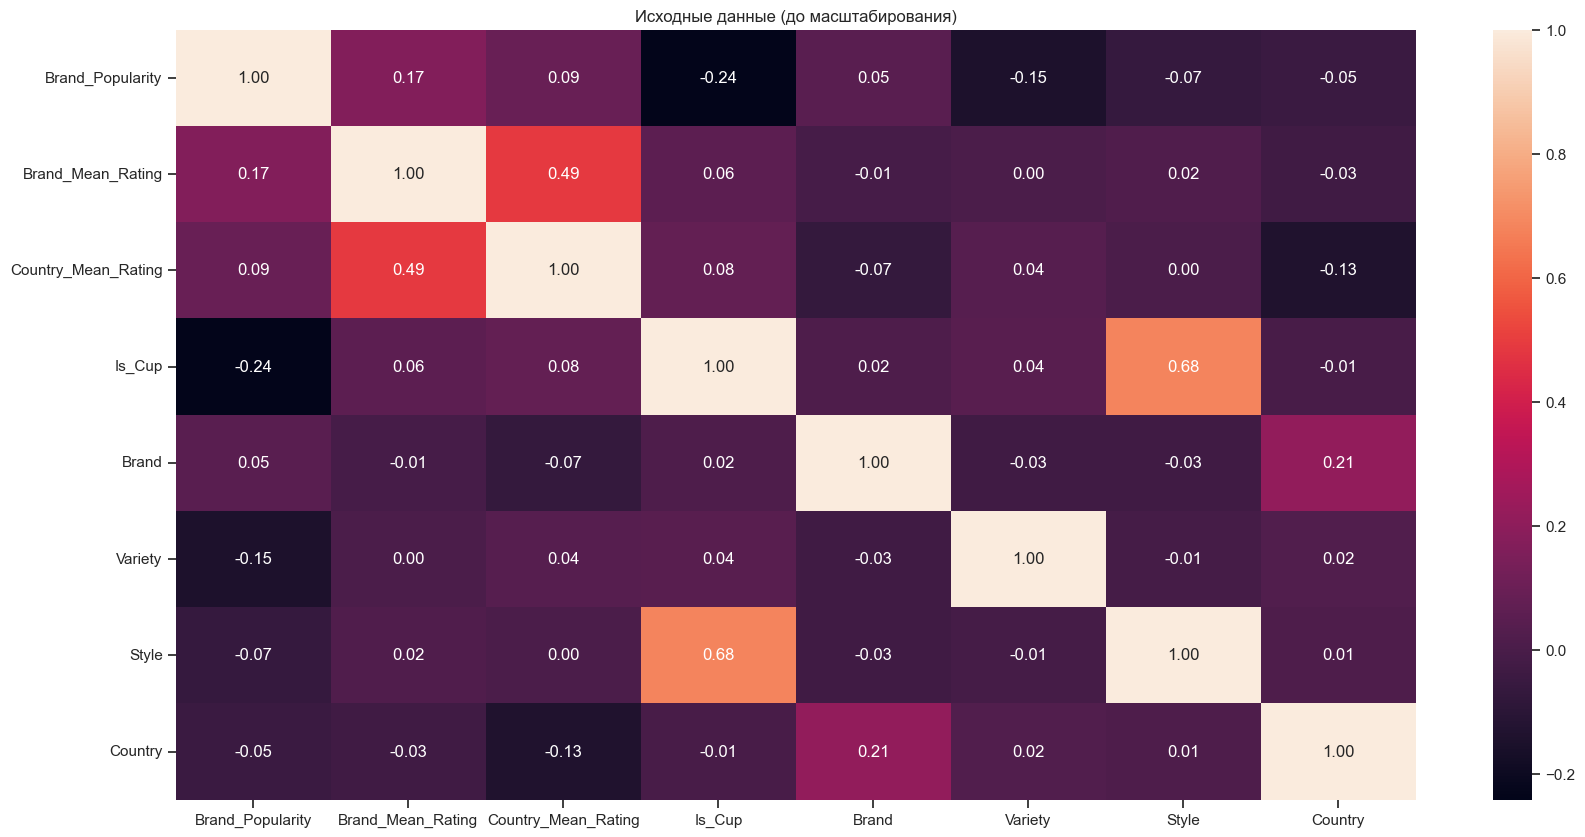

In [110]:
fig, ax = plt.subplots(figsize=(20,10))
sns.heatmap(data_all[corr_cols_1 + unsc_cols].corr(), annot=True, fmt='.2f')
ax.set_title('Исходные данные (до масштабирования)')
plt.show()

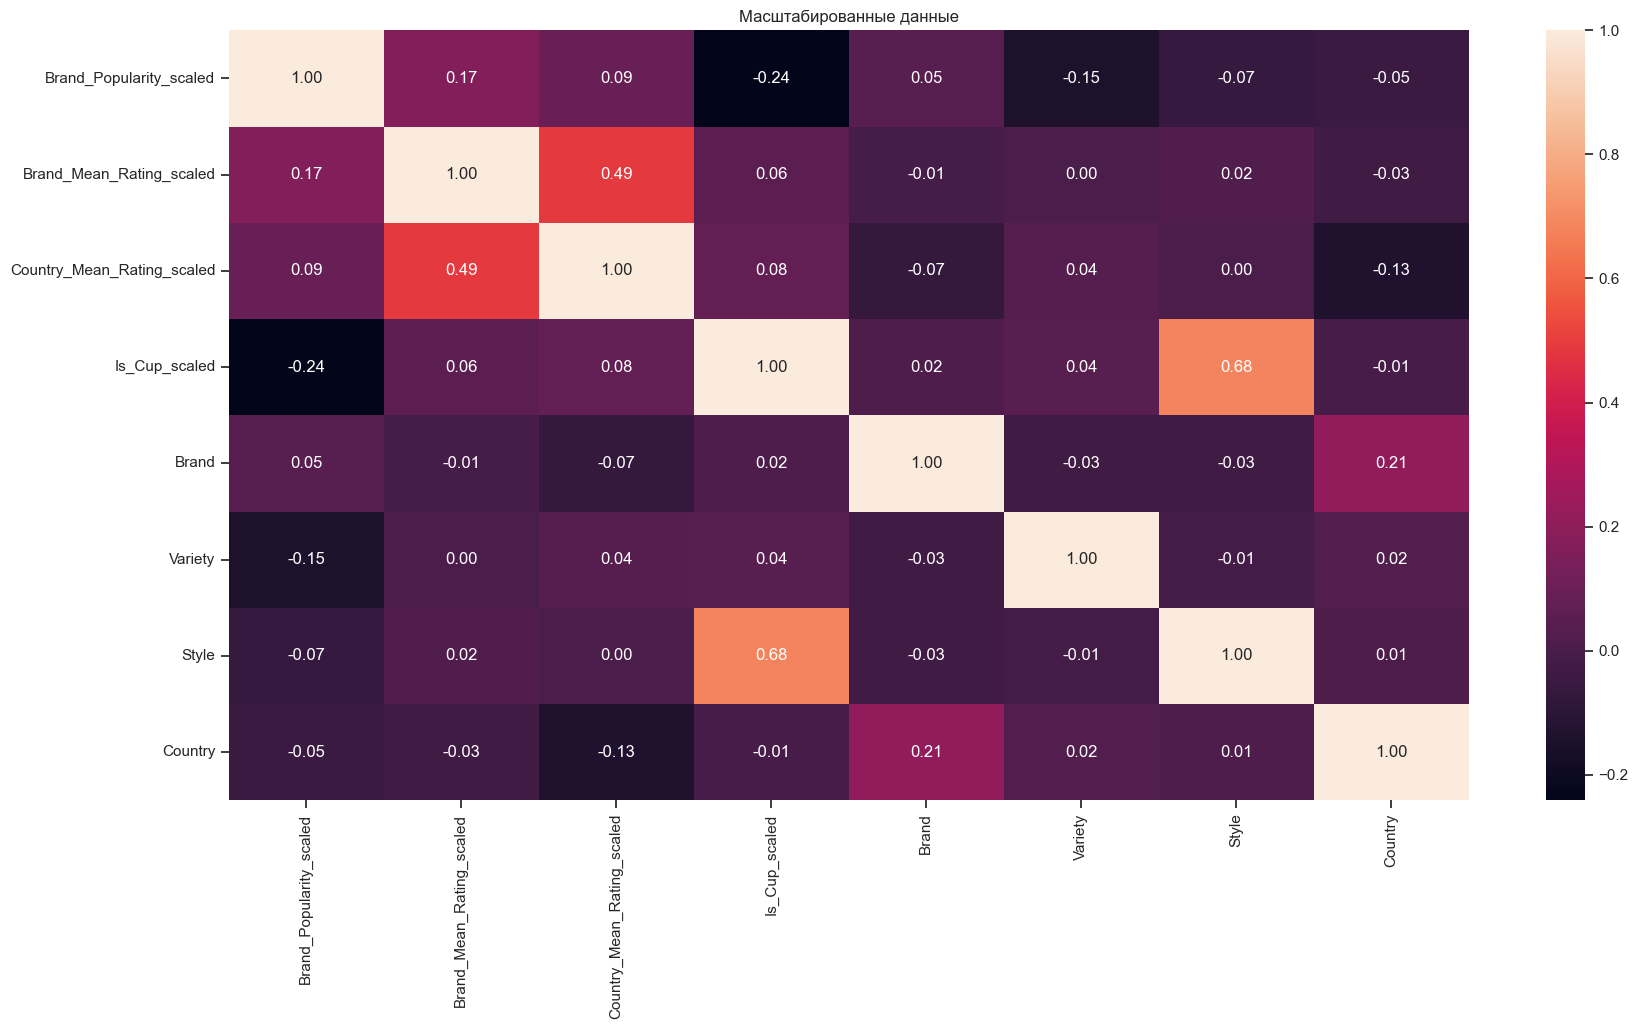

In [111]:
fig, ax = plt.subplots(figsize=(20,10))
sns.heatmap(data_all[corr_cols_2 + unsc_cols].corr(), annot=True, fmt='.2f')
ax.set_title('Масштабированные данные')
plt.show()

На основе корреляционной матрицы можно сделать следующие выводы:

- Корреляционные матрицы для исходных и масштабированных данных совпадают.
- Целевой признак классификации "Stars" наиболее сильно коррелирует со средним рейтингом бренда, со средним рейтингом по стране, в меньшей степени с популярностью бренда. Эти признаки обязательно следует оставить в модели классификации.
- Большие по модулю значения коэффициентов корреляции свидетельствуют о значимой корреляции между исходными признаками и целевым признаком.  На основании корреляционной матрицы можно сделать вывод о том, что данные позволяют построить модель машинного обучения. 

## Выбор метрик для последующей оценки качества моделей. 

### В качестве метрик для решения задачи классификации  будем использовать:

Метрики, формируемые на основе матрицы ошибок:

#### Метрика accuracy:

$acc = \frac{TP+TN}{TP+FP+TN+FN}$

#### Метрика precision:

Можно переводить как точность, но такой перевод совпадает с переводом метрики "accuracy".

$precision = \frac{TP}{TP+FP}$

Доля верно предсказанных классификатором положительных объектов, из всех объектов, которые классификатор верно или неверно определил как положительные.

Используется функция [precision_score.](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html#sklearn.metrics.precision_score)

#### Метрика recall (полнота):

$recall = \frac{TP}{TP+FN}$

Доля верно предсказанных классификатором положительных объектов, из всех действительно положительных объектов.

Используется функция [recall_score.](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html#sklearn.metrics.recall_score)

#### Метрика $F_1$-мера

Для того, чтобы объединить precision и recall в единую метрику используется $F_\beta$-мера, которая вычисляется как среднее гармоническое от precision и recall:

$F_\beta = (1+\beta^2) \cdot \frac{precision \cdot recall}{precision + recall}$

где $\beta$ определяет вес точности в метрике.

На практике чаще всего используют вариант F1-меры (которую часто называют F-мерой) при $\beta=1$:

$F_1 = 2 \cdot \frac{precision \cdot recall}{precision + recall}$

Для вычисления используется функция [f1_score.](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html#sklearn.metrics.f1_score)

#### Метрика ROC AUC

Основана на вычислении следующих характеристик:

$TPR = \frac{TP}{TP+FN}$ - True Positive Rate, откладывается по оси ординат. Совпадает с recall.

$FPR = \frac{FP}{FP+TN}$ - False Positive Rate, откладывается по оси абсцисс. Показывает какую долю из объектов отрицательного класса алгоритм предсказал неверно.

Идеальная ROC-кривая проходит через точки (0,0)-(0,1)-(1,1), то есть через верхний левый угол графика.

Чем сильнее отклоняется кривая от верхнего левого угла графика, тем хуже качество классификации.

В качестве количественной метрики используется площадь под кривой - ROC AUC (Area Under the Receiver Operating Characteristic Curve). Чем ниже проходит кривая тем меньше ее площадь и тем хуже качество классификатора.

Для получения ROC AUC используется функция [roc_auc_score.](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html#sklearn.metrics.roc_auc_score)

### Сохранение и визуализация метрик

Разработаем класс, который позволит сохранять метрики качества построенных моделей и реализует визуализацию метрик качества.

In [ ]:
class MetricLogger:
    
    def __init__(self):
        self.df = pd.DataFrame(
            {'metric': pd.Series([], dtype='str'),
            'alg': pd.Series([], dtype='str'),
            'value': pd.Series([], dtype='float')})

    def add(self, metric, alg, value):
        """
        Добавление значения
        """
        # Удаление значения если оно уже было ранее добавлено
        self.df.drop(self.df[(self.df['metric']==metric)&(self.df['alg']==alg)].index, inplace = True)
        # Добавление нового значения
        temp_df = pd.DataFrame({'metric': [metric], 'alg': [alg], 'value': [value]})
        self.df = pd.concat([self.df, temp_df], ignore_index=True)

    def get_data_for_metric(self, metric, ascending=True):
        """
        Формирование данных с фильтром по метрике
        """
        temp_data = self.df[self.df['metric']==metric]
        temp_data_2 = temp_data.sort_values(by='value', ascending=ascending)
        return temp_data_2['alg'].values, temp_data_2['value'].values
    
    def plot(self, str_header, metric, ascending=True, figsize=(5, 5)):
        """
        Вывод графика
        """
        array_labels, array_metric = self.get_data_for_metric(metric, ascending)
        fig, ax1 = plt.subplots(figsize=figsize)
        pos = np.arange(len(array_metric))
        rects = ax1.barh(pos, array_metric,
                         align='center',
                         height=0.5, 
                         tick_label=array_labels)
        ax1.set_title(str_header)
        for a,b in zip(pos, array_metric):
            plt.text(0.5, a-0.05, str(round(b,3)), color='white')
        plt.show()    

## Выбор наиболее подходящих моделей для решения задачи классификации

Для задачи классификации будем использовать следующие модели:
- Логистическая регрессия
- Метод ближайших соседей
- Машина опорных векторов
- Решающее дерево
- Случайный лес
- Градиентный бустинг

## Формирование обучающей и тестовой выборок на основе исходного набора данных.

In [113]:
# На основе масштабированных данных выделим 
# обучающую и тестовую выборки с помощью фильтра
train_data_all = data_all[data_all['dataset']=='TRAIN']
test_data_all = data_all[data_all['dataset']=='TEST1']
train_data_all.shape, test_data_all.shape

((2060, 14), (516, 14))

In [114]:
# Признаки для задачи классификации
task_clas_cols = [
    # Закодированные категориальные признаки
    'Brand',           # код бренда
    'Country',         # код страны
    'Style',           # код типа упаковки
    
    # Числовые признаки
    'Is_Cup',              # бинарный индикатор «Cup или нет»
    
    # Инженерные признаки (агрегаты по группе)
    'Brand_Popularity',    # доля записей бренда
    'Brand_Mean_Rating',   # средний рейтинг бренда
    'Country_Mean_Rating'  # средний рейтинг по стране
]

## Построение базового решения (baseline) для выбранных моделей без подбора гиперпараметров. Производится обучение моделей на основе обучающей выборки и оценка качества моделей на основе тестовой выборки.

### Решение задачи классификации

In [116]:
# Модели
clas_models = {'LogR': LogisticRegression(max_iter=1000), 
               'KNN_5':KNeighborsClassifier(n_neighbors=5),
               'SVC':SVC(probability=True),
               'Tree':DecisionTreeClassifier(),
               'RF':RandomForestClassifier(),
               'GB':GradientBoostingClassifier()}

In [117]:
# Сохранение метрик
clasMetricLogger = MetricLogger()

In [121]:
# Отрисовка ROC-кривой
def draw_roc_curve(y_true, y_score, ax, pos_label=1, average='micro'):
    fpr, tpr, thresholds = roc_curve(y_true, y_score, 
                                     pos_label=pos_label)
    roc_auc_value = roc_auc_score(y_true, y_score, average=average)
    #plt.figure()
    lw = 2
    ax.plot(fpr, tpr, color='darkorange',
             lw=lw, label='ROC curve (area = %0.2f)' % roc_auc_value)
    ax.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_xlim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('Receiver operating characteristic')
    ax.legend(loc="lower right")

In [124]:
def clas_train_model(model_name, model, clasMetricLogger):
    model.fit(clas_X_train, clas_Y_train)
    # Предсказание значений
    Y_pred = model.predict(clas_X_test)
    # Предсказание вероятности класса "1" для roc auc
    Y_pred_proba_temp = model.predict_proba(clas_X_test)
    Y_pred_proba = Y_pred_proba_temp[:,1]
    
    precision = precision_score(clas_Y_test.values, Y_pred, average='micro')
    recall = recall_score(clas_Y_test.values, Y_pred, average='micro')
    f1 = f1_score(clas_Y_test.values, Y_pred, average='micro')
    #roc_auc = roc_auc_score(clas_Y_test.values, Y_pred, average='micro', multi_class='ovr')
    
    clasMetricLogger.add('precision', model_name, precision)
    clasMetricLogger.add('recall', model_name, recall)
    clasMetricLogger.add('f1', model_name, f1)
    #clasMetricLogger.add('roc_auc', model_name, roc_auc)

    # Updated confusion matrix plotting
    cm = confusion_matrix(clas_Y_test.values, Y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['very_low', 'low', 'medium', 'high'])
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    
    fig.suptitle(model_name)
    plt.show()

In [125]:
for model_name, model in clas_models.items():
    clas_train_model(model_name, model, clasMetricLogger)

C:\Users\Bizar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Подбор гиперпараметров для выбранных моделей. 

In [126]:
# Function to perform GridSearchCV and plot results
def optimize_and_plot(model, param_grid, X_train, y_train, scoring, model_name, task_type):
    gs = GridSearchCV(model, param_grid, cv=5, scoring=scoring, n_jobs=-1, verbose=1)
    gs.fit(X_train, y_train)
    
    print(f"Best parameters for {model_name}: {gs.best_params_}")
    print(f"Best {scoring} score: {gs.best_score_:.4f}")
    
    # Plot performance vs parameter values
    plt.figure(figsize=(10, 6))
    if len(param_grid) == 1:  # Single parameter case
        param_name = list(param_grid.keys())[0]
        param_values = param_grid[param_name]
        
        # Handle cases where we can't plot all parameters
        if len(str(param_values[0])) < 50:  # Avoid plotting very complex parameter values
            plt.plot(param_values, gs.cv_results_['mean_test_score'], 'o-')
            plt.xlabel(param_name)
            plt.ylabel(f'Mean {scoring} score')
            plt.title(f'{model_name} performance vs {param_name}')
        else:
            print(f"Cannot plot for parameter {param_name} - values too complex")
    else:
        print("Multi-dimensional parameter space - skipping plot")
    
    plt.show()
    return gs.best_estimator_

### Для задачи классификации

In [127]:
clas_param_grids = {
    'LogR': {'C': np.logspace(-3, 3, 7), 'penalty': ['l2']},
    'KNN_5': {'n_neighbors': range(1, 100)},
    'SVC': [
        {'C': [0.1, 1, 10], 'kernel': ['linear']},
        {'C': [0.1, 1, 10], 'gamma': [0.1, 0.01, 0.001], 'kernel': ['rbf']}
    ],
    'Tree': {'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10]},
    'RF': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7, None],
        'min_samples_split': [2, 5, 10]
    },
    'GB': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.5],
        'max_depth': [3, 5, 7]
    }
}


Optimizing LogR...
Fitting 5 folds for each of 7 candidates, totalling 35 fits


C:\Users\Bizar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan]
  warnings.warn(


Best parameters for LogR: {'C': np.float64(0.001), 'penalty': 'l2'}
Best roc_auc score: nan
Multi-dimensional parameter space - skipping plot


C:\Users\Bizar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<Figure size 1000x600 with 0 Axes>


Optimizing KNN_5...
Fitting 5 folds for each of 99 candidates, totalling 495 fits
Best parameters for KNN_5: {'n_neighbors': 1}
Best roc_auc score: nan


C:\Users\Bizar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan]
  warnings.warn(


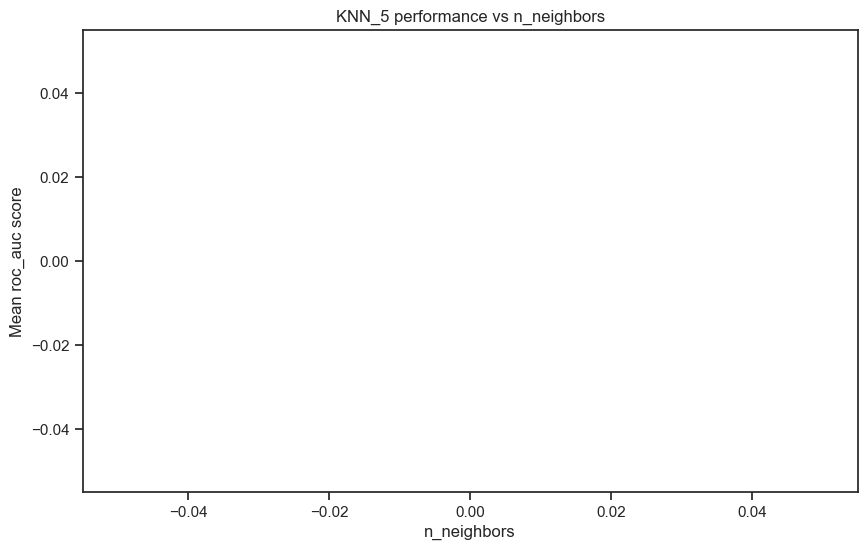


Optimizing SVC...
Fitting 5 folds for each of 12 candidates, totalling 60 fits


C:\Users\Bizar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best parameters for SVC: {'C': 0.1, 'kernel': 'linear'}
Best roc_auc score: nan
Multi-dimensional parameter space - skipping plot


<Figure size 1000x600 with 0 Axes>


Optimizing Tree...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters for Tree: {'max_depth': 3, 'min_samples_split': 2}
Best roc_auc score: nan
Multi-dimensional parameter space - skipping plot


...


Optimizing GB...
Fitting 5 folds for each of 27 candidates, totalling 135 fits


C:\Users\Bizar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best parameters for GB: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
Best roc_auc score: nan
Multi-dimensional parameter space - skipping plot


<Figure size 1000x600 with 0 Axes>

CPU times: total: 18.4 s
Wall time: 12min 17s


In [128]:
%%time
clas_best_models = {}
for model_name, model in clas_models.items():
    print(f"\nOptimizing {model_name}...")
    best_model = optimize_and_plot(
        model, 
        clas_param_grids[model_name], 
        clas_X_train, 
        clas_Y_train, 
        'roc_auc', 
        model_name,
        'classification'
    )
    clas_best_models[model_name + '_optimized'] = best_model

## Повторение пункта 8 для найденных оптимальных значений гиперпараметров. Сравнение качества полученных моделей с качеством baseline-моделей.

### Решение задачи классификации

In [129]:
# Train and evaluate optimized models
print("\nEvaluating optimized classification models:")
for model_name, model in clas_best_models.items():
    clas_train_model(model_name, model, clasMetricLogger)


Evaluating optimized classification models:


C:\Users\Bizar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Сравнение качества моделей

In [130]:
def compare_metrics(original_models, optimized_models, metric_logger, metric_name, plot = True, stat = True):
    original_scores = []
    optimized_scores = []
    model_names = []
    
    # Get all metrics data for the specified metric
    metric_data = metric_logger.df[metric_logger.df['metric'] == metric_name]
    
    for model_name in original_models.keys():
        optimized_name = model_name + '_optimized'
        
        # Get original model score
        original_score = metric_data[metric_data['alg'] == model_name]['value']
        if not original_score.empty:
            original_scores.append(original_score.values[0])
        else:
            continue  # Skip if original model not found
            
        # Get optimized model score
        optimized_score = metric_data[metric_data['alg'] == optimized_name]['value']
        if not optimized_score.empty:
            optimized_scores.append(optimized_score.values[0])
            model_names.append(model_name)
    
    if not model_names:  # No data to compare
        print(f"No comparison data available for metric: {metric_name}")
        return
    
    if stat:
        print(metric_name)
        for mod in range(len(model_names)):
            print("For model", model_names[mod], " - Baseline: ", original_scores[mod], "; Optimal: ", optimized_scores[mod])
        print("\n")
    
    if plot:
        # Create comparison plot
        x = range(len(model_names))
        plt.figure(figsize=(12, 6))
        plt.bar(x, original_scores, width=0.4, label='Original')
        plt.bar([i + 0.4 for i in x], optimized_scores, width=0.4, label='Optimized')
        plt.xticks([i + 0.2 for i in x], model_names, rotation=45)
        plt.ylabel(metric_name)
        plt.title(f'Comparison of {metric_name} between original and optimized models')
        plt.legend()
        plt.tight_layout()
        plt.show()
    

No comparison data available for metric: roc_auc
f1
For model LogR  - Baseline:  0.6511627906976745 ; Optimal:  0.501937984496124
For model KNN_5  - Baseline:  0.47674418604651164 ; Optimal:  0.45155038759689925
For model SVC  - Baseline:  0.501937984496124 ; Optimal:  0.6550387596899225
For model Tree  - Baseline:  0.5968992248062015 ; Optimal:  0.6589147286821705
For model RF  - Baseline:  0.6666666666666666 ; Optimal:  0.5833333333333334
For model GB  - Baseline:  0.6589147286821705 ; Optimal:  0.6124031007751938




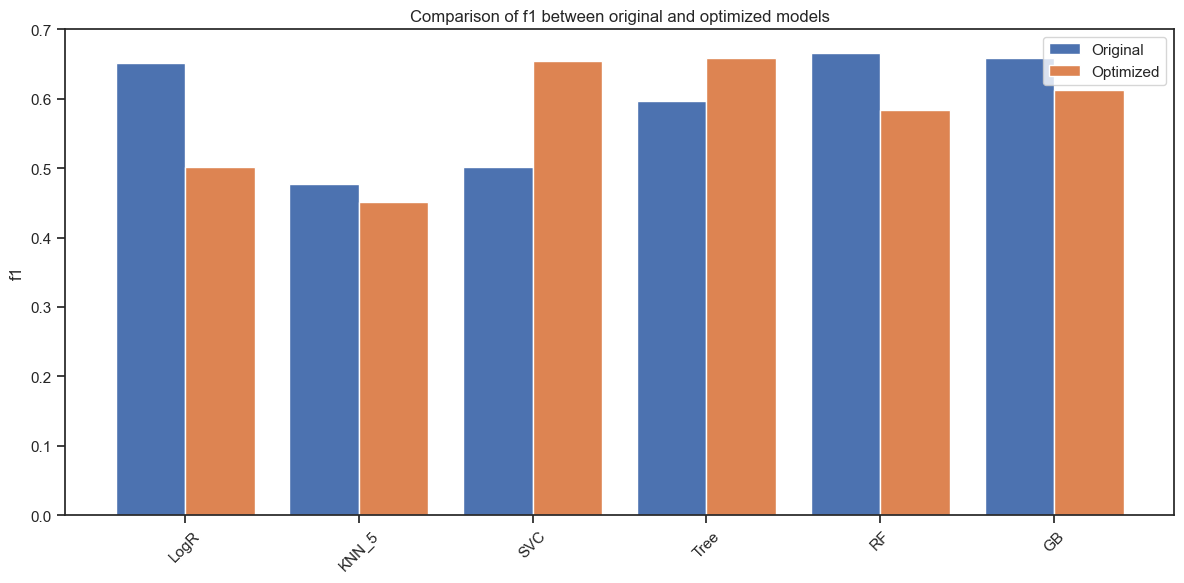

No comparison data available for metric: accuracy
precision
For model LogR  - Baseline:  0.6511627906976745 ; Optimal:  0.501937984496124
For model KNN_5  - Baseline:  0.47674418604651164 ; Optimal:  0.45155038759689925
For model SVC  - Baseline:  0.501937984496124 ; Optimal:  0.6550387596899225
For model Tree  - Baseline:  0.5968992248062015 ; Optimal:  0.6589147286821705
For model RF  - Baseline:  0.6666666666666666 ; Optimal:  0.5833333333333334
For model GB  - Baseline:  0.6589147286821705 ; Optimal:  0.6124031007751938


recall
For model LogR  - Baseline:  0.6511627906976745 ; Optimal:  0.501937984496124
For model KNN_5  - Baseline:  0.47674418604651164 ; Optimal:  0.45155038759689925
For model SVC  - Baseline:  0.501937984496124 ; Optimal:  0.6550387596899225
For model Tree  - Baseline:  0.5968992248062015 ; Optimal:  0.6589147286821705
For model RF  - Baseline:  0.6666666666666666 ; Optimal:  0.5833333333333334
For model GB  - Baseline:  0.6589147286821705 ; Optimal:  0.61240310

In [131]:
compare_metrics(clas_models, clas_best_models, clasMetricLogger, 'roc_auc')
compare_metrics(clas_models, clas_best_models, clasMetricLogger, 'f1')
compare_metrics(clas_models, clas_best_models, clasMetricLogger, 'accuracy', plot=False)
compare_metrics(clas_models, clas_best_models, clasMetricLogger, 'precision', plot=False)
compare_metrics(clas_models, clas_best_models, clasMetricLogger, 'recall', plot=False)

## Формирование выводов о качестве построенных моделей на основе выбранных метрик.

### Решение задачи классификации

In [132]:
# Метрики качества модели
clas_metrics = clasMetricLogger.df['metric'].unique()
clas_metrics

array(['precision', 'recall', 'f1'], dtype=object)

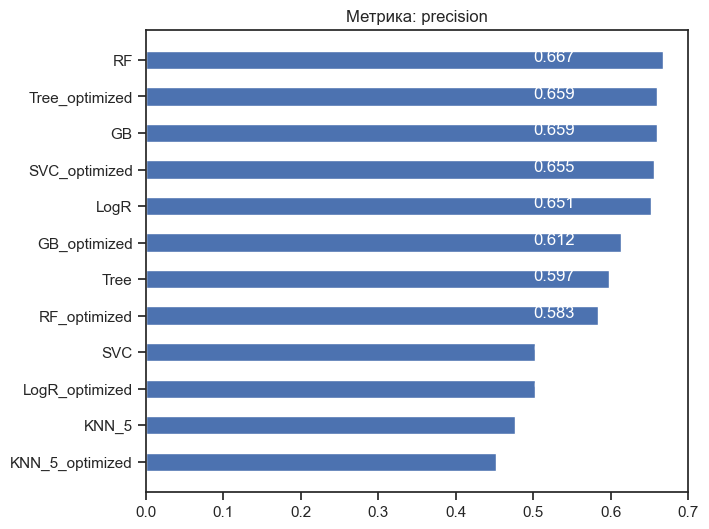

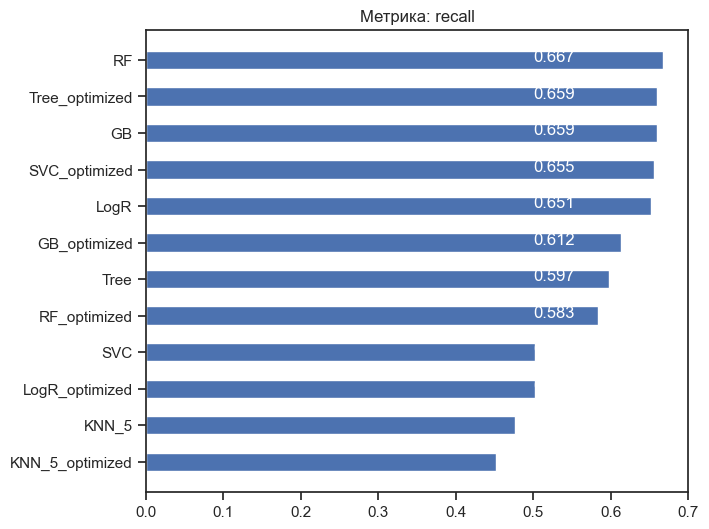

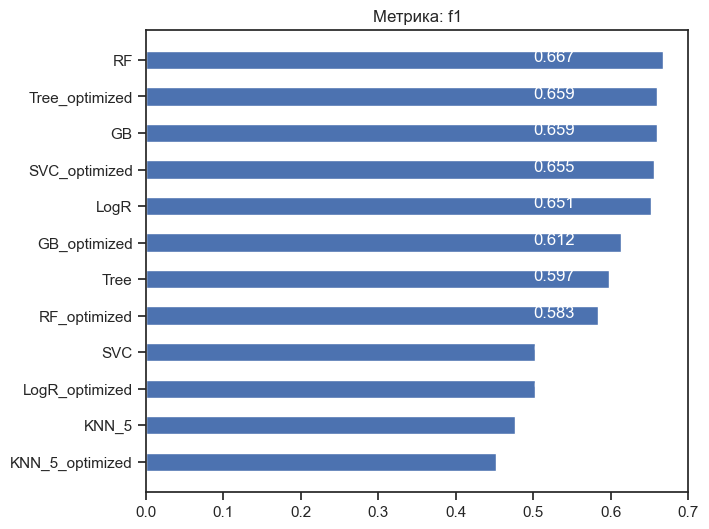

In [133]:
# Построим графики метрик качества модели
for metric in clas_metrics:
    clasMetricLogger.plot('Метрика: ' + metric, metric, figsize=(7, 6))

**Вывод: на основании трех метрик из четырех используемых,  лучшей оказались модели градиентного бустинга и случайного леса. В некоторых случаях могло оказаться лучше KNN**

## Самые важные признаки

### Классификация - Gradient Boosting

In [134]:
gbc = GradientBoostingClassifier().fit(clas_X_train, clas_Y_train)
# Предсказание значений
Y_pred = gbc.predict(clas_X_test)

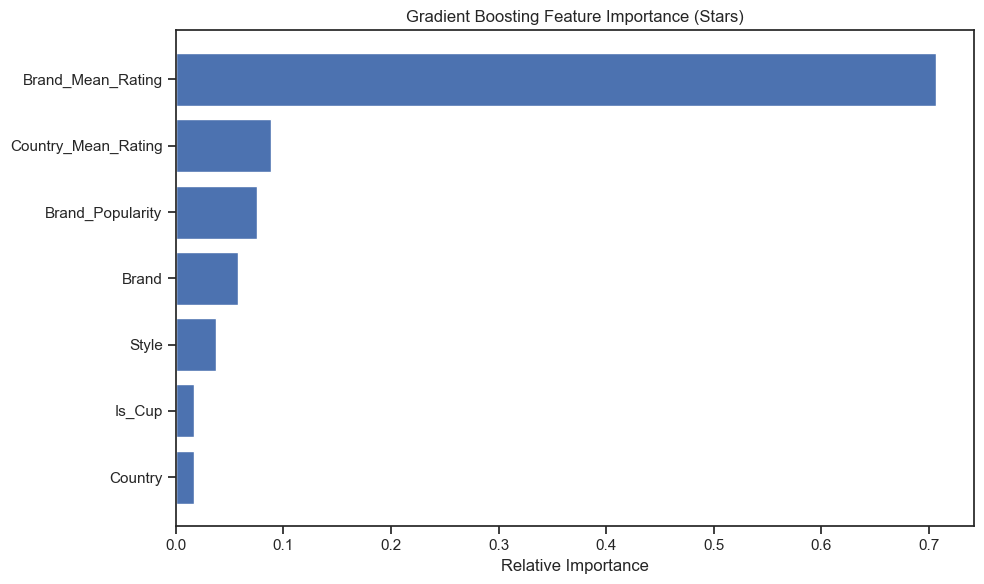

Top 5 Features for Gradient Boosting:
Brand_Mean_Rating: 0.7065
Country_Mean_Rating: 0.0889
Brand_Popularity: 0.0754
Brand: 0.0579
Style: 0.0376


In [135]:
# Get feature importance
feature_importance = gbc.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5

# Plot
plt.figure(figsize=(10, 6))
plt.barh(pos, feature_importance[sorted_idx], align='center')
plt.yticks(pos, np.array(clas_X_train.columns)[sorted_idx])
plt.title('Gradient Boosting Feature Importance (Stars)')
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

# Print top 5 features
print("Top 5 Features for Gradient Boosting:")
for i in sorted_idx[-5:][::-1]:
    print(f"{clas_X_train.columns[i]}: {feature_importance[i]:.4f}")

## **Интерпретация важности признаков в задаче прогнозирования рейтинга рамена**

Полученные результаты показывают, какие факторы наиболее сильно влияют на **классификацию рейтинга рамена** согласно модели градиентного бустинга. Разберём их в контексте потребительских предпочтений и особенностей продукта.

---

### **Классификация (Stars) – Что определяет высокую оценку рамена?**

#### **Топ-5 признаков:**

1. **`Brand_Mean_Rating`** – **Средний рейтинг бренда**

   * Самый весомый фактор (0.7065): если у бренда в целом высокие оценки, отдельные его продукты тоже получают больше баллов.

2. **`Country_Mean_Rating`** – **Средний рейтинг по стране**

   * Значимый региональный контекст (0.0889): предпочтения по странам влияют на восприятие вкуса и рецептуры.

3. **`Brand_Popularity`** – **Популярность бренда**

   * Мера известности (0.0754): бренды с большим количеством отзывов чаще получают более высокие оценки.

4. **`Brand:`** – **Тип упаковки**

   * Небольшой эффект (0.0579): бренд в целом.

5. **`Style`** – **Булев индикатор «Cup или нет»**

   * ебольшой эффект (0.0376): Cup, Pack или Bowl влияют на удобство потребления и, косвенно, на оценку качества.

---

### **Общий вывод:**

1. **Репутация бренда (`Brand_Mean_Rating`) – ключевой фактор.**
2. **Региональные предпочтения (`Country_Mean_Rating`) – важны для локализации продукта.**
3. **Популярность (`Brand_Popularity`) – даёт дополнительный эффект доверия.**
4. **Упаковка (`Style`, `Brand`) – влияет на удобство и восприятие качества.**

Данные показывают, что для точного предсказания рейтинга рамена особенно важно учитывать **средние оценки по бренду и стране**, а также **аспекты упаковки**.

---

#### **Практические рекомендации:**
✅ **Фокус на бренде:** при выводе на рынок новых вкусов ориентируйтесь на бренды с уже высокой средней оценкой.

✅ **Локализация:** адаптируйте рецептуру и маркетинг под вкусовые предпочтения конкретных стран.

✅ **Упаковка:** исследуйте формат Cup для повышения удобства и визуальной привлекательности.

✅ **Маркетинговые кампании:** повышайте узнаваемость бренда, чтобы увеличить его популярность и, как следствие, рейтинг.

✅ **Мониторинг отзывов:** систематически собирайте и анализируйте оценки, чтобы быстро реагировать на изменения предпочтений.
